In [ ]:
!source myenv/Scripts/activate

/bin/bash: line 1: myenv/Scripts/activate: No such file or directory


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv('medicine_names_dataset.csv')

In [ ]:
df.sample(10)

,Input,Output
82808,seroqul,seroquel
78678,rvomin,revomin
61134,mrphine,morphine
16606,cenexadi,cenexadin
63311,nabumtone,nabumetone
39900,leetiracetam,levetiracetam
97899,olar,zolar
58677,inirin,minirin
65321,omeprazol,omeprazole
33438,fluoxtine,fluoxetine


# Data Cleaning

In [ ]:
df.shape

(101197, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101197 entries, 0 to 101196
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   Input   101197 non-null  object
 1   Output  101197 non-null  object
dtypes: object(2)
memory usage: 1.5+ MB


In [ ]:
df['Input'] = df['Input'].str.lower()
df['Output'] = df['Output'].str.lower()

In [ ]:
df.duplicated().sum()

np.int64(78452)

In [ ]:
duplicates = df[df.duplicated()]
print(duplicates)


               Input          Output
1      carithromycin  clarithromycin
2      carithromycin  clarithromycin
3      carithromycin  clarithromycin
4      carithromycin  clarithromycin
5      carithromycin  clarithromycin
...              ...             ...
99123        zopidem        zolpidem
99124        zopidem        zolpidem
99125        zopidem        zolpidem
99126        zopidem        zolpidem
99127        zopidem        zolpidem

[78452 rows x 2 columns]


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
Input,0
Output,0


In [ ]:
df['Input'] = df['Input'].astype(str)
df['Output'] = df['Output'].astype(str)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22745 entries, 0 to 101196
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Input   22745 non-null  object
 1   Output  22745 non-null  object
dtypes: object(2)
memory usage: 533.1+ KB


In [ ]:
type(df['Input'])

pandas.core.series.Series

In [ ]:
df.describe(include='all')

,Input,Output
count,22745,22745
unique,21411,3837
top,mont,lisdexamfetamine
freq,7,16


# EDA

In [ ]:
!pip install python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 42.6 MB/s eta 0:00:00


In [ ]:
import Levenshtein
# Unique drugs and their frequencies
unique_drugs = df['Output'].nunique()
drug_counts = df['Output'].value_counts()

print("\nNumber of Unique Drugs:", unique_drugs)
print("\nTop 5 Most Frequent Drugs:")
print(drug_counts.head())

# String length analysis
df['Input_Length'] = df['Input'].str.len()
df['Output_Length'] = df['Output'].str.len()

print("\nInput Length Stats:")
print(df['Input_Length'].describe())
print("\nOutput Length Stats:")
print(df['Output_Length'].describe())

# Optional: Levenshtein distance (if package is installed)
df['Levenshtein_Distance'] = df.apply(lambda x: Levenshtein.distance(x['Input'], x['Output']), axis=1)
print("\nLevenshtein Distance Stats:")
print(df['Levenshtein_Distance'].describe())


Number of Unique Drugs: 3837

Top 5 Most Frequent Drugs:
Output
lisdexamfetamine    16
clarithromycin      14
levothyroxine       13
acetaminophen       13
nuberol forte       13
Name: count, dtype: int64

Input Length Stats:
count    22745.000000
mean         6.678743
std          1.703506
min          4.000000
25%          5.000000
50%          7.000000
75%          8.000000
max         16.000000
Name: Input_Length, dtype: float64

Output Length Stats:
count    22745.000000
mean         7.678743
std          1.703506
min          5.000000
25%          6.000000
50%          8.000000
75%          9.000000
max         17.000000
Name: Output_Length, dtype: float64

Levenshtein Distance Stats:
count    22745.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: Levenshtein_Distance, dtype: float64


In [ ]:
df['Output'].unique()

array(['clarithromycin', 'acetaminophen', 'actifed', ..., 'zyvisc',
       'zyzer', 'zyzolide'], dtype=object)

In [ ]:
len(df['Output'].unique())

3837

In [ ]:
df['Input_length'] = df['Input'].str.len()
df['Output_length'] = df['Output'].str.len()

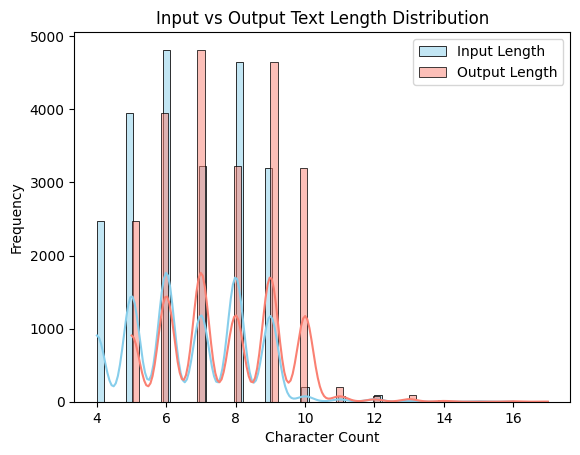

In [ ]:

sns.histplot(df['Input_length'], kde=True, color='skyblue', label='Input Length')
sns.histplot(df['Output_length'], kde=True, color='salmon', label='Output Length')
plt.legend()
plt.title("Input vs Output Text Length Distribution")
plt.xlabel("Character Count")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# ! pip install wordcloud

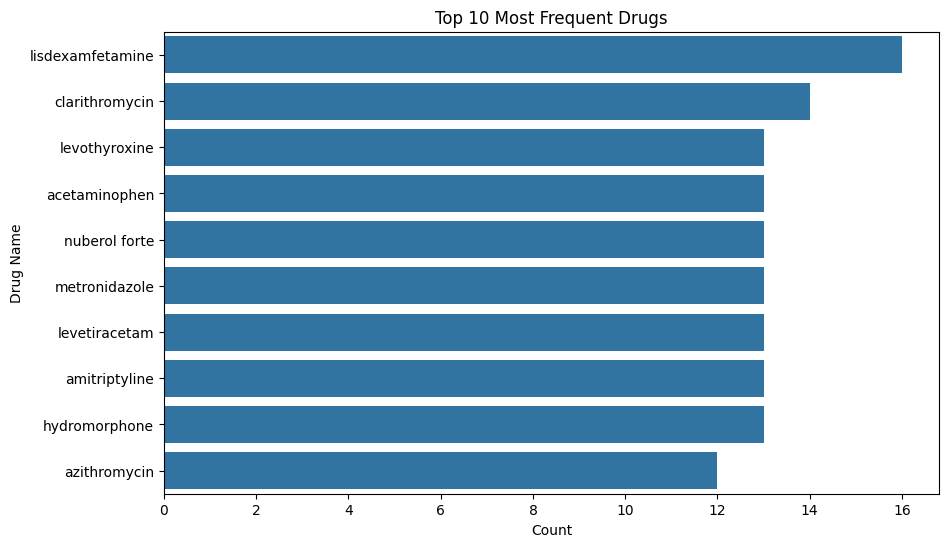

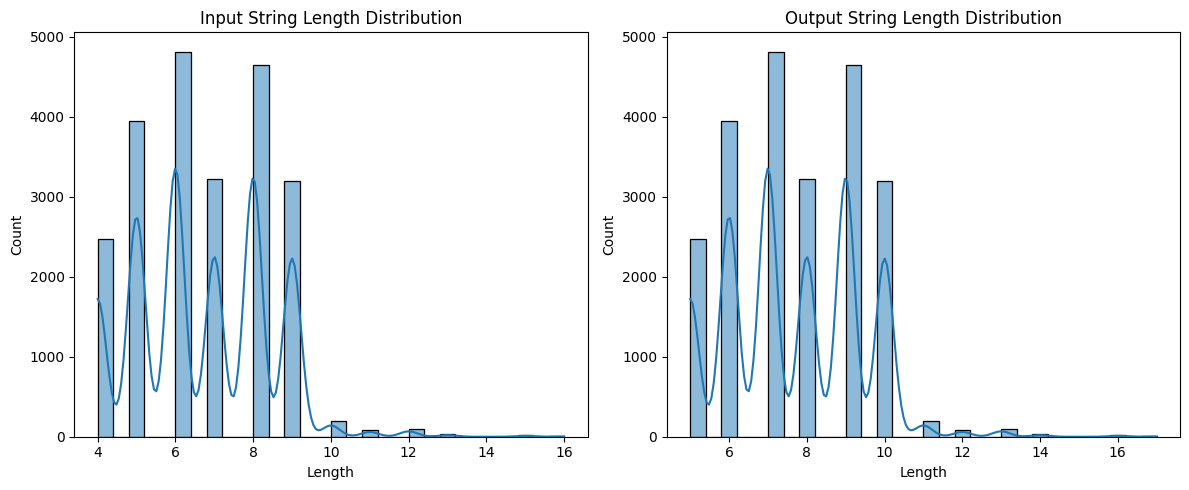

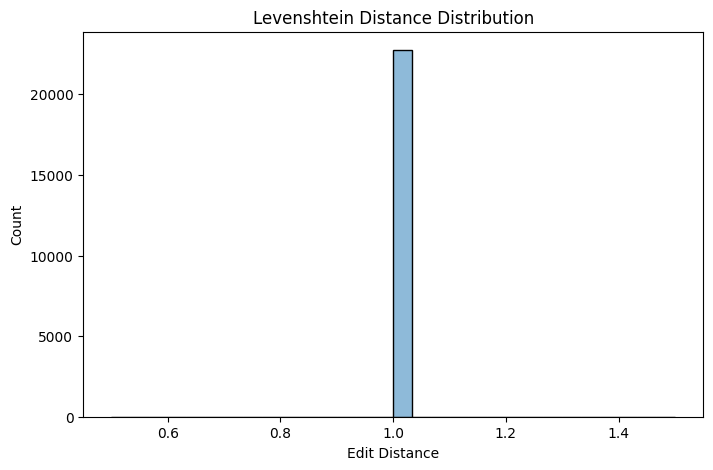

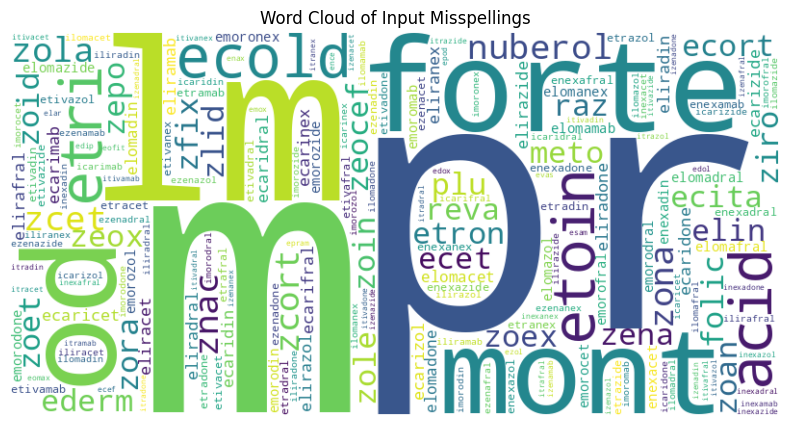

In [ ]:
# Plot top 10 drugs by frequency
plt.figure(figsize=(10, 6))
sns.barplot(x=drug_counts.head(10).values, y=drug_counts.head(10).index)
plt.title('Top 10 Most Frequent Drugs')
plt.xlabel('Count')
plt.ylabel('Drug Name')
plt.show()

# Plot string length distributions
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Input_Length'], bins=30, kde=True)
plt.title('Input String Length Distribution')
plt.xlabel('Length')
plt.subplot(1, 2, 2)
sns.histplot(df['Output_Length'], bins=30, kde=True)
plt.title('Output String Length Distribution')
plt.xlabel('Length')
plt.tight_layout()
plt.show()

# Plot Levenshtein distance (if computed)
plt.figure(figsize=(8, 5))
sns.histplot(df['Levenshtein_Distance'], bins=30, kde=True)
plt.title('Levenshtein Distance Distribution')
plt.xlabel('Edit Distance')
plt.show()

# Optional: Word cloud for Input
from wordcloud import WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(df['Input']))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Input Misspellings')
plt.show()

In [ ]:
from collections import Counter
# Perfect matches (Input == Output)
perfect_matches = df[df['Input'] == df['Output']]
print("\nNumber of Perfect Matches:", len(perfect_matches))
print("\nExamples of Perfect Matches:")
print(perfect_matches.head())

# Average Levenshtein distance per drug
avg_distance = df.groupby('Output')['Levenshtein_Distance'].mean().sort_values(ascending=False)
print("\nTop 5 Drugs by Average Levenshtein Distance:")
print(avg_distance.head())

# Short inputs (length <= 2)
short_inputs = df[df['Input_Length'] <= 2]
print("\nShort Inputs (Length <= 2):")
print(short_inputs[['Input', 'Output']].head())

# Common character substitutions (simplified, requires custom analysis)
# Example: Count frequency of characters in Input vs. Output
input_chars = Counter(''.join(df['Input']))
output_chars = Counter(''.join(df['Output']))
print("\nTop 5 Input Characters:", input_chars.most_common(5))
print("Top 5 Output Characters:", output_chars.most_common(5))


Number of Perfect Matches: 0

Examples of Perfect Matches:
Empty DataFrame
Columns: [Input, Output, Input_Length, Output_Length, Levenshtein_Distance, Input_length, Output_length]
Index: []

Top 5 Drugs by Average Levenshtein Distance:
Output
zyzolide         1.0
acetaminophen    1.0
actifed          1.0
actos            1.0
acyclovir        1.0
Name: Levenshtein_Distance, dtype: float64

Short Inputs (Length <= 2):
Empty DataFrame
Columns: [Input, Output]
Index: []

Top 5 Input Characters: [('e', 18822), ('a', 15230), ('o', 14043), ('i', 13019), ('r', 10551)]
Top 5 Output Characters: [('e', 21817), ('a', 17207), ('o', 16315), ('i', 14892), ('r', 11978)]


In [ ]:
df.sample(10)

,Input,Output,Input_Length,Output_Length,Levenshtein_Distance,Input_length,Output_length
94819,zart,zaart,4,5,1,4,5
97469,itotec,zitotec,6,7,1,6,7
59119,mofeyl,mofetyl,6,7,1,6,7
86102,tinexafrl,tinexafral,9,10,1,9,10
96280,zroach,zeroach,6,7,1,6,7
100637,zyfn,zyfen,4,5,1,4,5
16218,elecoxib,celecoxib,8,9,1,8,9
50548,meoneuron,meconeuron,9,10,1,9,10
50658,meipan,medipan,6,7,1,6,7
97768,zoent,zodent,5,6,1,5,6


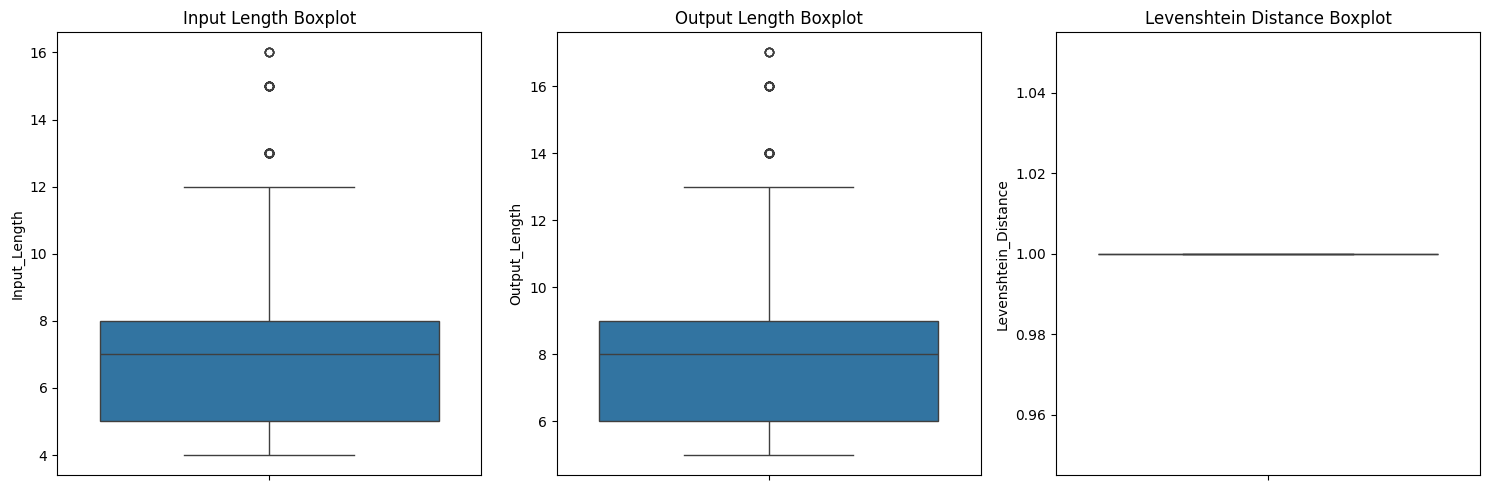

In [ ]:
# Derive numerical features
df['Input_Length'] = df['Input'].str.len()
df['Output_Length'] = df['Output'].str.len()
df['Levenshtein_Distance'] = df.apply(lambda x: Levenshtein.distance(x['Input'], x['Output']), axis=1)

# Visualize boxplots
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(y=df['Input_Length'])
plt.title('Input Length Boxplot')
plt.subplot(1, 3, 2)
sns.boxplot(y=df['Output_Length'])
plt.title('Output Length Boxplot')
plt.subplot(1, 3, 3)
sns.boxplot(y=df['Levenshtein_Distance'])
plt.title('Levenshtein Distance Boxplot')
plt.tight_layout()
plt.show()


In [ ]:
df.head()

,Input,Output,Input_Length,Output_Length,Levenshtein_Distance,Input_length,Output_length
0,carithromycin,clarithromycin,13,14,1,13,14
11,claithromycin,clarithromycin,13,14,1,13,14
22,clarihromycin,clarithromycin,13,14,1,13,14
33,clarithomycin,clarithromycin,13,14,1,13,14
44,clarithrmycin,clarithromycin,13,14,1,13,14


In [ ]:
df['Tokenized_Input'] = df['Input'].apply(lambda x: list(x))
df['Tokenized_Output'] = df['Output'].apply(lambda x: list(x))

In [ ]:
df.head()

,Input,Output,Input_Length,Output_Length,Levenshtein_Distance,Input_length,Output_length,Tokenized_Input,Tokenized_Output
0,carithromycin,clarithromycin,13,14,1,13,14,"[c, a, r, i, t, h, r, o, m, y, c, i, n]","[c, l, a, r, i, t, h, r, o, m, y, c, i, n]"
11,claithromycin,clarithromycin,13,14,1,13,14,"[c, l, a, i, t, h, r, o, m, y, c, i, n]","[c, l, a, r, i, t, h, r, o, m, y, c, i, n]"
22,clarihromycin,clarithromycin,13,14,1,13,14,"[c, l, a, r, i, h, r, o, m, y, c, i, n]","[c, l, a, r, i, t, h, r, o, m, y, c, i, n]"
33,clarithomycin,clarithromycin,13,14,1,13,14,"[c, l, a, r, i, t, h, o, m, y, c, i, n]","[c, l, a, r, i, t, h, r, o, m, y, c, i, n]"
44,clarithrmycin,clarithromycin,13,14,1,13,14,"[c, l, a, r, i, t, h, r, m, y, c, i, n]","[c, l, a, r, i, t, h, r, o, m, y, c, i, n]"


In [ ]:
df.shape

(22745, 9)

In [ ]:
df2 = df[['Tokenized_Input','Tokenized_Output']]

In [ ]:
df2.sample(10)

,Tokenized_Input,Tokenized_Output
94662,"[x, t, r, a, c, e, t]","[x, a, t, r, a, c, e, t]"
77255,"[r, a, b, i, z, e, a]","[r, a, b, i, z, e, n, a]"
23699,"[d, i, m, o, r, o, d, r, a]","[d, i, m, o, r, o, d, r, a, l]"
31053,"[t, o, c, e, l]","[e, t, o, c, e, l]"
53009,"[m, t, a, l, y, s, e]","[m, e, t, a, l, y, s, e]"
97249,"[z, p, p, i, g, o]","[z, i, p, p, i, g, o]"
30255,"[e, o, c, a, r, d]","[e, s, o, c, a, r, d]"
26169,"[e, b, a, o, n, t]","[e, b, a, m, o, n, t]"
30874,"[e, i, c, h, o, l, i, c]","[e, t, i, c, h, o, l, i, c]"
91799,"[v, e, t, r, a, f, a, l]","[v, e, t, r, a, f, r, a, l]"


In [ ]:
df2.head()

,Tokenized_Input,Tokenized_Output
0,"[v, a, s, t, i, n]","[a, v, a, s, t, i, n]"
1,"[a, s, t, i, n]","[a, v, a, s, t, i, n]"
2,"[v, a, t, i, n]","[a, v, a, s, t, i, n]"
3,"[v, s, t, i, n]","[a, v, a, s, t, i, n]"
4,"[a, v, s, t, n]","[a, v, a, s, t, i, n]"


In [ ]:
df2.sample(10)

,Tokenized_Input,Tokenized_Output
2016,"[m, o, r, h, i, n, e]","[m, o, r, p, h, i, n, e]"
1625,"[l, y, s, d, e, x, a, m, f, e, t, a, m, i, n, e]","[l, i, s, d, e, x, a, m, f, e, t, a, m, i, n, e]"
992,"[d, i, v, a, l, p, r, e, o, x]","[d, i, v, a, l, p, r, o, e, x]"
1155,"[f, l, a, g, l, y]","[f, l, a, g, y, l]"
790,"[c, e, r, s, t, o, r]","[c, r, e, s, t, o, r]"
952,"[d, i, a, z, p, e, a, m]","[d, i, a, z, e, p, a, m]"
2521,"[p, e, d, n, i, s, o, n, e]","[p, r, e, d, n, i, s, o, n, e]"
520,"[b, e, n, r, d, r, y, l]","[b, e, n, a, d, r, y, l]"
13,"[a, t, o, s]","[a, c, t, o, s]"
2335,"[p, a, n, t, o, p, r, a, z, o, l, o]","[p, a, n, t, o, p, r, a, z, o, l, e]"


In [ ]:
# Create vocabulary
all_tokens = set(['<PAD>', '<EOS>'])  # Initialize with special tokens
for seq in df['Tokenized_Input']:
    all_tokens.update(seq)
for seq in df['Tokenized_Output']:
    all_tokens.update(seq)
token_to_idx = {token: idx for idx, token in enumerate(sorted(all_tokens))}
idx_to_token = {idx: token for token, idx in token_to_idx.items()}

In [ ]:
# Step 2: Convert tokens to indices
X = [[token_to_idx[token] for token in seq] for seq in df2['Tokenized_Input']]
y = [[token_to_idx[token] for token in seq] for seq in df2['Tokenized_Output']]

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Step 3: Pad sequences
max_len = max(max(len(seq) for seq in X), max(len(seq) for seq in y))
X_padded = pad_sequences(X, maxlen=max_len, padding='post', value=token_to_idx['<PAD>'])
y_padded = pad_sequences(y, maxlen=max_len, padding='post', value=token_to_idx['<PAD>'])

In [ ]:
X_padded

array([[ 7,  5, 22, ...,  4,  4,  4],
       [ 7, 16,  5, ...,  4,  4,  4],
       [ 7, 16,  5, ...,  4,  4,  4],
       ...,
       [30, 29, 30, ...,  4,  4,  4],
       [30, 29, 30, ...,  4,  4,  4],
       [30, 30, 19, ...,  4,  4,  4]], dtype=int32)

In [ ]:
y_padded

array([[ 7, 16,  5, ...,  4,  4,  4],
       [ 7, 16,  5, ...,  4,  4,  4],
       [ 7, 16,  5, ...,  4,  4,  4],
       ...,
       [30, 29, 30, ...,  4,  4,  4],
       [30, 29, 30, ...,  4,  4,  4],
       [30, 29, 30, ...,  4,  4,  4]], dtype=int32)

In [ ]:
max_len

17

In [ ]:
from tensorflow.keras.utils import to_categorical

# Step 4: Convert output to one-hot encoding
vocab_size = len(token_to_idx)
y_one_hot = to_categorical(y_padded, num_classes=vocab_size)

In [ ]:
from sklearn.model_selection import train_test_split

# Step 5: Split data
X_train, X_test, y_train, y_test = train_test_split(X_padded, y_one_hot, test_size=0.2, random_state=42, shuffle=True)

In [ ]:
# ! pip install --upgrade tensorflow

In [ ]:
import tensorflow as tf
tf.config.run_functions_eagerly(True)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, TimeDistributed, Dense, Bidirectional, GRU
from tensorflow.keras.optimizers import Adam

embedding_dim = 128
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, mask_zero=True),
    LSTM(256, return_sequences=True, dropout=0.3, recurrent_dropout=0.3),
    TimeDistributed(Dense(vocab_size, activation='softmax'))
])

In [ ]:
# Step 7: Compile model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define early stopping callback
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

# Define model checkpoint callback to save the best model
checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Train model with callbacks
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=2,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, checkpoint],
    verbose=1
)

Epoch 1/20
136/821 ━━━━━━━━━━━━━━━━━━━━ 7:57 697ms/step - accuracy: 0.4763 - loss: 1.9509

ERROR:tensorflow:==================================
Object was never used (type <class 'tensorflow.python.ops.tensor_array_ops.TensorArray'>):
If you want to mark it as used call its "mark_used()" method.
It was originally created here:
  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/ops/while_loop.py", line 488, in while_loop
    loop_vars = body(*loop_vars)  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/ops/while_loop.py", line 479, in <lambda>
    body = lambda i, lv: (i + 1, orig_body(*lv))  File "/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/rnn.py", line 385, in _step
    return (time + 1, output_ta_t, tuple(flat_new_output)) + tuple(  File "/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/rnn.py", line 382, in <genexpr>
    for ta, out in zip(output_ta_t, flat_new_output)  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/util/tf_should_use.py", line 288, in wrapped
    return _add_shoul

821/821 ━━━━━━━━━━━━━━━━━━━━ 0s 705ms/step - accuracy: 0.6429 - loss: 1.4140
Epoch 1: val_accuracy improved from -inf to 0.85401, saving model to best_model.keras
821/821 ━━━━━━━━━━━━━━━━━━━━ 638s 775ms/step - accuracy: 0.6431 - loss: 1.4135 - val_accuracy: 0.8540 - val_loss: 0.5729
Epoch 2/20
821/821 ━━━━━━━━━━━━━━━━━━━━ 0s 741ms/step - accuracy: 0.8434 - loss: 0.5667
Epoch 2: val_accuracy improved from 0.85401 to 0.86071, saving model to best_model.keras
821/821 ━━━━━━━━━━━━━━━━━━━━ 667s 812ms/step - accuracy: 0.8434 - loss: 0.5667 - val_accuracy: 0.8607 - val_loss: 0.4860
Epoch 3/20
821/821 ━━━━━━━━━━━━━━━━━━━━ 0s 726ms/step - accuracy: 0.8541 - loss: 0.4764
Epoch 3: val_accuracy improved from 0.86071 to 0.87135, saving model to best_model.keras
821/821 ━━━━━━━━━━━━━━━━━━━━ 653s 796ms/step - accuracy: 0.8541 - loss: 0.4764 - val_accuracy: 0.8714 - val_loss: 0.4321
Epoch 4/20
821/821 ━━━━━━━━━━━━━━━━━━━━ 0s 732ms/step - accuracy: 0.8725 - loss: 0.3884
Epoch 4: val_accuracy improved f

In [ ]:
 model.save('Word_Reconstruct_LSTM.keras')

In [ ]:
from tensorflow.keras.models import load_model
model = load_model("Word_Reconstruct_LSTM.keras")

In [ ]:
def predict_sequence(input_seq):
    # Convert input sequence to indices
    input_indices = [token_to_idx.get(token, token_to_idx['<PAD>']) for token in input_seq]
    input_padded = pad_sequences([input_indices], maxlen=max_len, padding='post', value=token_to_idx['<PAD>'])

    # Predict
    pred = model.predict(input_padded, verbose=0)
    pred_indices = np.argmax(pred, axis=-1)[0]

    # Convert indices back to tokens, stopping at <EOS> or <PAD>
    pred_tokens = []
    for idx in pred_indices:
        if idx == token_to_idx['<PAD>'] or idx == token_to_idx['<EOS>']:
            break
        pred_tokens.append(idx_to_token[idx])

    return pred_tokens

# Test multiple examples
test_cases = [
    {
        'input': list('panadl'),  # Damaged version of 'panadol'
        'expected': list('panadol')
    },
    {
        'input': list('asati'),  # Damaged version of 'avastin'
        'expected': list('avastin')
    },
    {
        'input': list('amlodipne'),  # Damaged version of 'amlodipine'
        'expected': list('amlodipine')
    },
    {
        'input': list('hydrcodone'),  # Damaged version of 'hydrocodone'
        'expected': list('hydrocodone')
    },
    {
        'input': list('morhine'),  # Damaged version of 'morphine'
        'expected': list('morphine')
    }
]
# Run predictions
for i, test_case in enumerate(test_cases, 1):
    predicted_output = predict_sequence(test_case['input'])
    print(f"Test Case {i}:")
    print(f"Input: {''.join(test_case['input'])}")
    print(f"Predicted Output: {''.join(predicted_output)}")
    print(f"Expected Output: {''.join(test_case['expected'])}")
    print()

Test Case 1:
Input: panadl
Predicted Output: panadol
Expected Output: panadol

Test Case 2:
Input: asati
Predicted Output: avastin
Expected Output: avastin

Test Case 3:
Input: amlodipne
Predicted Output: amlodipine
Expected Output: amlodipine

Test Case 4:
Input: hydrcodone
Predicted Output: hydrocodone
Expected Output: hydrocodone

Test Case 5:
Input: morhine
Predicted Output: morphine
Expected Output: morphine



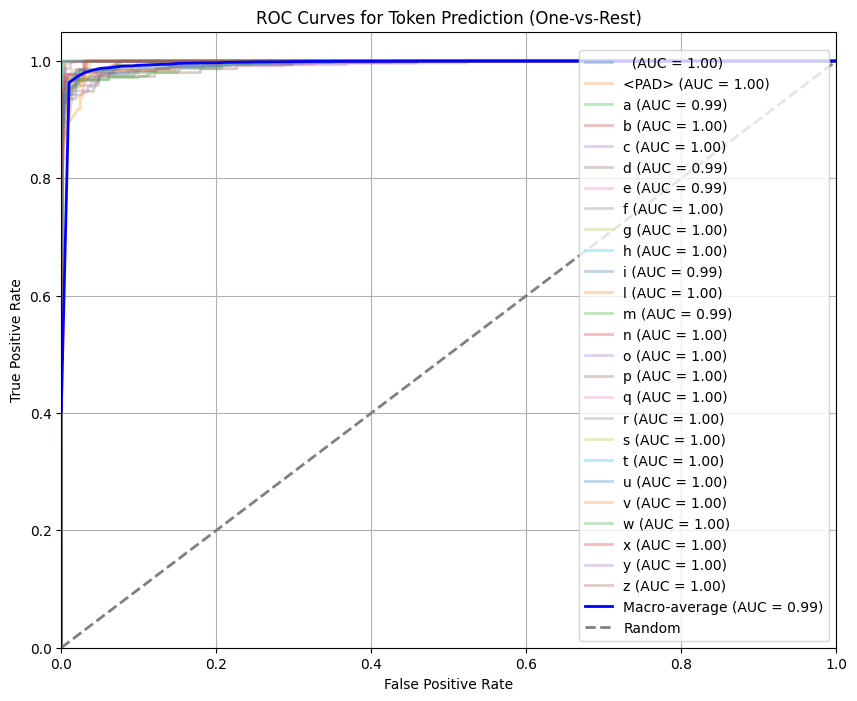

In [ ]:
from sklearn.metrics import roc_curve, auc
# ROC curve plotting
def plot_roc_curve(X_test, y_test, model, token_to_idx, idx_to_token):
    # Predict probabilities
    y_pred = model.predict(X_test, verbose=0)
    y_true = np.argmax(y_test, axis=-1)  # Convert one-hot encoded y_test to class indices

    # Get vocab_size from token_to_idx or idx_to_token
    vocab_size = len(token_to_idx)

    # Flatten predictions and true labels
    y_pred_flat = y_pred.reshape(-1, vocab_size)
    y_true_flat = y_true.reshape(-1)
    y_true_one_hot = to_categorical(y_true_flat, num_classes=vocab_size)

    plt.figure(figsize=(10, 8))
    mean_fpr = np.linspace(0, 1, 100)
    tprs = []
    aucs = []

    # Plot ROC curve for each class
    for i in range(vocab_size):
        if i in y_true_flat:  # Check if class is present in true labels
            fpr, tpr, _ = roc_curve(y_true_one_hot[:, i], y_pred_flat[:, i])
            roc_auc = auc(fpr, tpr)
            aucs.append(roc_auc)
            tprs.append(np.interp(mean_fpr, fpr, tpr))
            plt.plot(fpr, tpr, lw=2, alpha=0.3, label=f'{idx_to_token.get(i, f"Class {i}")} (AUC = {roc_auc:.2f})')

    # Plot macro-average ROC curve if there are valid classes
    if tprs:
        mean_tpr = np.mean(tprs, axis=0)
        mean_auc = auc(mean_fpr, mean_tpr)
        plt.plot(mean_fpr, mean_tpr, color='b', lw=2, label=f'Macro-average (AUC = {mean_auc:.2f})')

    # Plot diagonal line for random guessing
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves for Token Prediction (One-vs-Rest)')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()  # Display the plot instead of saving

# Plot ROC curve
plot_roc_curve(X_test, y_test, model, token_to_idx, idx_to_token)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Assuming model, X_test, and y_test are defined from your previous code
# Predict on test set
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=-1)  # Convert predicted probabilities to class indices
y_true_classes = np.argmax(y_test, axis=-1)  # Convert one-hot encoded y_test to class indices

# Flatten the arrays for metric calculations
y_pred_flat = y_pred_classes.reshape(-1)
y_true_flat = y_true_classes.reshape(-1)

# Compute metrics
accuracy = accuracy_score(y_true_flat, y_pred_flat)
precision = precision_score(y_true_flat, y_pred_flat, average='macro', zero_division=0)
recall = recall_score(y_true_flat, y_pred_flat, average='macro', zero_division=0)
f1 = f1_score(y_true_flat, y_pred_flat, average='macro', zero_division=0)

# Print metrics
print(f"Testing Accuracy: {accuracy:.4f}")
print(f"Precision (Macro): {precision:.4f}")
print(f"Recall (Macro): {recall:.4f}")
print(f"F1-Score (Macro): {f1:.4f}")

/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


Testing Accuracy: 0.9491
Precision (Macro): 0.9051
Recall (Macro): 0.9032
F1-Score (Macro): 0.9034


In [ ]:
import numpy as np
from Levenshtein import distance as levenshtein_distance

def compute_cer(y_true, y_pred, idx_to_token):
    """
    Compute Character Error Rate (CER) for predicted and true token sequences.

    Args:
        y_true: True labels (numpy array of shape (samples, timesteps) with token indices)
        y_pred: Predicted labels (numpy array of shape (samples, timesteps) with token indices)
        idx_to_token: Dictionary mapping token indices to characters/tokens

    Returns:
        cer: Character Error Rate (float)
    """
    total_distance = 0
    total_length = 0

    for true_seq, pred_seq in zip(y_true, y_pred):
        # Convert token indices to character sequences
        true_chars = ''.join([idx_to_token.get(idx, '') for idx in true_seq if idx in idx_to_token])
        pred_chars = ''.join([idx_to_token.get(idx, '') for idx in pred_seq if idx in idx_to_token])

        # Compute Levenshtein distance
        dist = levenshtein_distance(true_chars, pred_chars)
        total_distance += dist
        total_length += len(true_chars)

    # Calculate CER (avoid division by zero)
    cer = total_distance / total_length if total_length > 0 else 0
    return cer

# Assuming model, X_test, y_test, and idx_to_token are defined from your previous code
# Predict on test set
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=-1)  # Convert predicted probabilities to token indices
y_true_classes = np.argmax(y_test, axis=-1)  # Convert one-hot encoded y_test to token indices

# Compute CER
cer = compute_cer(y_true_classes, y_pred_classes, idx_to_token)

# Print CER
print(f"Character Error Rate (CER): {cer:.4f} ({cer * 100:.2f}%)")

/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


Character Error Rate (CER): 0.0231 (2.31%)


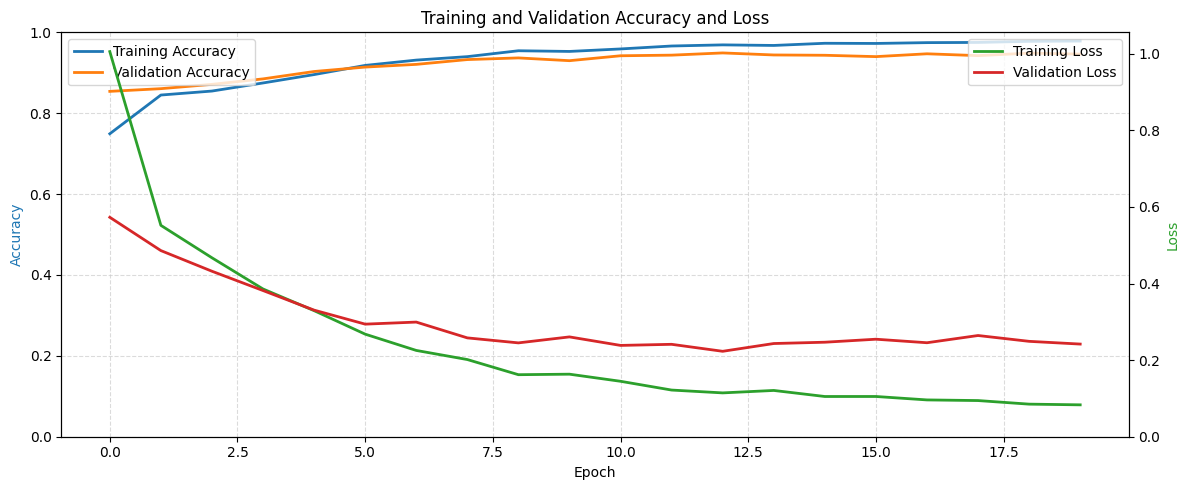

In [ ]:
# Create the plot
plt.figure(figsize=(12, 5))

# Plot accuracy (training and validation) on the left y-axis
plt.plot(history.history['accuracy'], label='Training Accuracy', color='#1f77b4', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#ff7f0e', linewidth=2)

# Create a second y-axis for loss
ax = plt.gca()  # Get current axis
ax_loss = ax.twinx()  # Create twin axis for loss
ax_loss.plot(history.history['loss'], label='Training Loss', color='#2ca02c', linewidth=2)
ax_loss.plot(history.history['val_loss'], label='Validation Loss', color='#d62728', linewidth=2)

# Set labels and titles
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy', color='#1f77b4')
ax_loss.set_ylabel('Loss', color='#2ca02c')
plt.title('Training and Validation Accuracy and Loss')

# Set axis limits (assuming accuracy and loss are normalized between 0 and 1)
ax.set_ylim(0, 1)
ax_loss.set_ylim(0, max(max(history.history['loss']), max(history.history['val_loss'])) * 1.05)

# Add legends
ax.legend(loc='upper left')
ax_loss.legend(loc='upper right')

# Add grid
ax.grid(True, color='#cccccc', linestyle='--', alpha=0.7)
ax_loss.grid(False)  # Avoid overlapping grid lines

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()

In [ ]:
import pickle

# Save history as a pickle file
with open('Simple_LSTM_History.pkl', 'wb') as file:
    pickle.dump(history.history, file)
